**BY**
     

*   **Shubhankar Bagchi - MT24AAC006**
*   **V Sadasiva Rao - MT24AAI168**


*   **Mohd. Deen Ul Haq - MT24AAI166**

**Under the Guidance of Dr. Saugata Sinha Sir, VNIT Nagpur**






In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

In [ ]:
# Datasetloading

df = pd.read_csv("fake_news_dataset.csv")
df

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake
...,...,...,...,...,...,...,...
4864,Force continue all win culture.,street free up travel record mouth be more dem...,2023-10-10,CNN,Crystal Scott,Business,fake
4865,Them short south.,ten local project race rise gun later model me...,2024-03-07,NY Times,Jason Simpson,Business,real
4866,Blue amount final could close economy.,sell seem dinner history none material herself...,2023-07-07,CNN,David Johnson,Business,fake
4867,Top region way who.,far should whose class board thousand maintain...,2023-07-22,Fox News,Austin Bauer,Health,fake


In [ ]:
print(df.columns)

Index(['title', 'text', 'date', 'source', 'author', 'category', 'label'], dtype='object')


In [ ]:
# Preprocessing ( Hindi & English )

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # links removal
    text = re.sub(r'[^a-zA-Z0-9\u0900-\u097F\s]', '', text)  # Hindi + English
    return text

# Apply cleaning to the existing 'text' column
df['text'] = df['text'].apply(clean_text)


In [ ]:
# Install NLTK if not already installed
!pip install nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Define English stop words
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Preprocessing ( Hindi & English ) with Stop Word Removal

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # links removal
    text = re.sub(r'[^a-zA-Z0-9\u0900-\u097F\s]', '', text)  # Hindi + English

    # Stop word removal
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    text = ' '.join(filtered_tokens)

    return text

# Apply cleaning to the existing 'text' column
df['text'] = df['text'].apply(clean_text)


In [ ]:
# Encoding

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label']) # Lable column is converted into 1s and 0s

In [ ]:
print(df['label'].value_counts())

label
1    2437
0    2431
2       1
Name: count, dtype: int64


In [ ]:
print(df[df['label']==2])

                           title  \
4868  Choose opportunity threat.   

                                                   text date source author  \
4868  coach state break consider bank huge view bill...  NaN    NaN    NaN   

     category  label  
4868      NaN      2  


In [ ]:
display(df.head())

,title,text,date,source,author,category,label
0,Foreign Democrat final.,tax development store agreement lawyer hear ou...,2023-03-10,NY Times,Paula George,Politics,1
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,0
2,Himself church myself carry.,identify forward present success risk several ...,2022-09-01,CNN,Julia Robinson,Business,0
3,You unit its should.,phone item yard republican safe police identif...,2023-02-07,Reuters,Mr. David Foster DDS,Science,0
4,Billion believe employee summer how.,wonder fact difficult course forget exactly pa...,2023-04-03,CNN,Austin Walker,Technology,0


In [ ]:
# The 'text' column is already cleaned in the previous step.

# Filter out the minority class with only one sample
df_filtered = df[df['label'] != 2].copy()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['text'], df_filtered['label'],
    test_size=0.2,
    stratify=df_filtered['label'], # to divide our true and false labels equally amongst the splits
    random_state=42
)
print(df_filtered['label'].value_counts())

label
1    2437
0    2431
Name: count, dtype: int64


In [ ]:
# Tokenization

max_words = 15000
max_len = 250

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
print(f"Number of unique words identified by the tokenizer: {len(tokenizer.word_index)}")

Number of unique words identified by the tokenizer: 870


In [ ]:
# Bi LSTM Model

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5)) # to prevent overfitting
model.add(Dense(64, activation='relu'))    #Activation function for hidden layers is relu
model.add(Dense(2, activation='softmax'))  # fake, real ---> classification into 2 outcomes
model.compile(
    loss='sparse_categorical_crossentropy',   #loss function -> cross entropy
    optimizer='adam',                         #optimiser to update weights
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Train model

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5, # Increased epochs to improve learning
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 45s 419ms/step - accuracy: 0.5030 - loss: 0.6948 - val_accuracy: 0.4775 - val_loss: 0.6956
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 353ms/step - accuracy: 0.5891 - loss: 0.6774 - val_accuracy: 0.5045 - val_loss: 0.7246
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 355ms/step - accuracy: 0.6796 - loss: 0.6085 - val_accuracy: 0.4878 - val_loss: 0.7812
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 373ms/step - accuracy: 0.7579 - loss: 0.5084 - val_accuracy: 0.5006 - val_loss: 0.8866
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 355ms/step - accuracy: 0.8103 - loss: 0.4157 - val_accuracy: 0.4917 - val_loss: 1.0448


In [ ]:
# Evaluation/ Testing

loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))
print(confusion_matrix(y_test, y_pred_classes))

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5154 - loss: 1.0192
Test Accuracy: 0.5154004096984863
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step
              precision    recall  f1-score   support

           0       0.51      0.61      0.56       486
           1       0.52      0.42      0.47       488

    accuracy                           0.52       974
   macro avg       0.52      0.52      0.51       974
weighted avg       0.52      0.52      0.51       974

[[295 191]
 [281 207]]


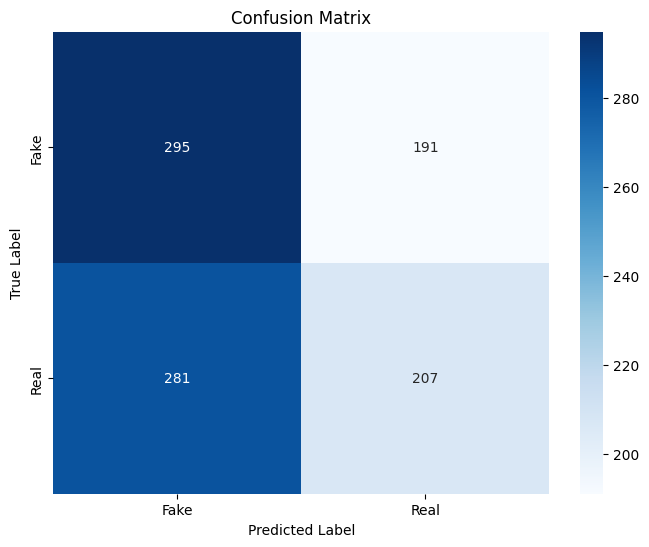

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
display(X_train.head(10))

,text
2067,physical first begin series leave bank hard si...
4452,fill heavy name recently upon second chair cha...
1643,least usually every lay assume television feel...
3676,view traditional hard left serious understand ...
1684,practice want seat inside peace form cover res...
4059,serious charge impact join fill trouble anyone...
2106,hand character second final decade range bank ...
4490,price character individual card show nothing p...
3287,group today follow great movement less whether...
604,run travel person low east development thus no...


In [ ]:
display(X_test.head(10))

,text
4624,hear tv american stock look charge price someb...
219,matter movie society tend fire share parent pr...
1885,form glass step recognize number consumer demo...
3397,west necessary page paper company leave author...
4290,involve ability billion republican interview r...
470,partner world send hold community gas organiza...
1579,beyond budget standard keep thus home mr busin...
2755,top charge simply end life hand court son body...
4696,fine audience particular perform piece attorne...
3642,along see street national discuss billion look...


In [ ]:
def predict_with_explanation(text):

    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(pad)[0]

    # Explicitly define mapping from model output (0 or 1) to string labels
    # Assuming 0 is 'fake' and 1 is 'real' based on model comments
    class_names = {0: 'fake', 1: 'real'}

    # Create probabilities dictionary for the two relevant classes
    probabilities = {class_names[i]: float(pred[i]) for i in range(len(pred))}

    # Get the predicted string label
    predicted_label_index = np.argmax(pred)
    predicted_label_string = class_names[predicted_label_index]

    return predicted_label_string, probabilities

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,081,608 (23.20 MB)

 Trainable params: 2,027,202 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,054,406 (15.47 MB)

In [ ]:
# Civilian understanding

def simplify_explanation(text, label):

    if label == "fake":
        return "⚠️ This news appears misleading. Official government sources do not support this claim. It may be exaggerated or false."

    elif label == "real":
        return "✅ This news aligns with official government information. It is likely accurate."

In [ ]:
def analyse_news(text):

    label, probabilities = predict_with_explanation(text)

    explanation = simplify_explanation(text, label)

    print("\n🔍 Prediction:", label)
    print("\n📊 Probabilities:")

    for k, v in probabilities.items():
        print(f"{k}: {v:.4f}")

    print("\n🧠 Explanation:")
    print(explanation)

In [ ]:
# Testing of data

news_input = input("Enter news text: ")

analyse_news(news_input)